In [1]:
print("AKHIL C")
print("24BAD007")

AKHIL C
24BAD007


# Scenario 1 – Customer Segmentation using K-Means Clustering


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
df = pd.read_csv('Mall_Customers.csv')
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 3. Data Preprocessing

In [3]:
print(df.isnull().sum())
print(df.describe().round(2))

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
       CustomerID     Age  Annual Income (k$)  Spending Score (1-100)
count      200.00  200.00              200.00                  200.00
mean       100.50   38.85               60.56                   50.20
std         57.88   13.97               26.26                   25.82
min          1.00   18.00               15.00                    1.00
25%         50.75   28.75               41.50                   34.75
50%        100.50   36.00               61.50                   50.00
75%        150.25   49.00               78.00                   73.00
max        200.00   70.00              137.00                   99.00


## 4. Select Relevant Features

In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Feature matrix shape: {X_scaled.shape}")

Feature matrix shape: (200, 2)


## 5. Elbow Method to Determine Optimal K

In [5]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

print("K | Inertia | Silhouette")
for k, i, s in zip(K_range, inertias, sil_scores):
    print(f"{k} | {i:.2f}  | {s:.4f}")

K | Inertia | Silhouette
2 | 269.69  | 0.3213
3 | 157.70  | 0.4666
4 | 108.92  | 0.4939
5 | 65.57  | 0.5547
6 | 55.06  | 0.5399
7 | 44.86  | 0.5281
8 | 37.23  | 0.4552
9 | 32.39  | 0.4571
10 | 29.98  | 0.4432


## 6 & 7. Apply K-Means and Assign Cluster Labels

In [6]:
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print(df['Cluster'].value_counts().sort_index())

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [7]:
final_inertia = kmeans.inertia_
final_sil = silhouette_score(X_scaled, df['Cluster'])
print(f"Inertia (K={k_optimal}):          {final_inertia:.4f}")
print(f"Silhouette Score (K={k_optimal}): {final_sil:.4f}")

Inertia (K=5):          65.5684
Silhouette Score (K=5): 0.5547


## 9. Interpret Cluster Characteristics

In [8]:
summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print(summary)

          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        42.7                55.3                    49.5
1        32.7                86.5                    82.1
2        25.3                25.7                    79.4
3        41.1                88.2                    17.1
4        45.2                26.3                    20.9


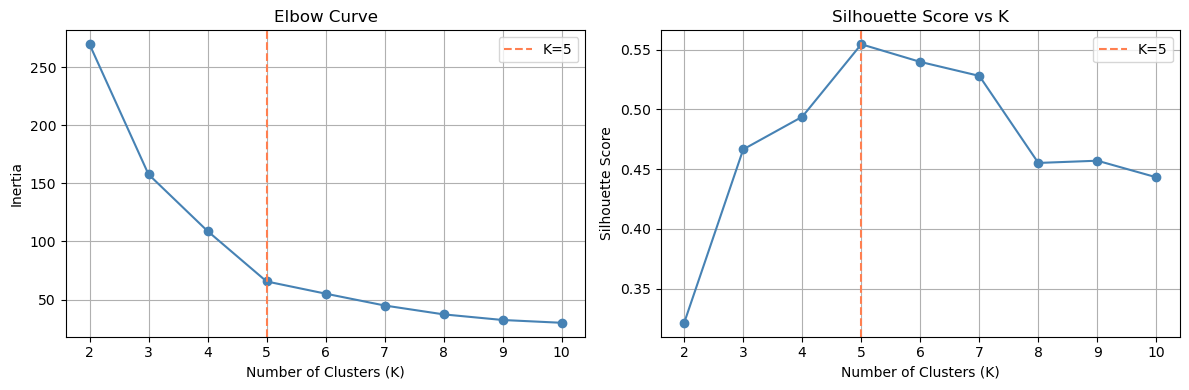

In [9]:
# Elbow curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].axvline(k_optimal, linestyle='--', color='coral', label=f'K={k_optimal}')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Curve')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(list(K_range), sil_scores, marker='o', color='steelblue')
axes[1].axvline(k_optimal, linestyle='--', color='coral', label=f'K={k_optimal}')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

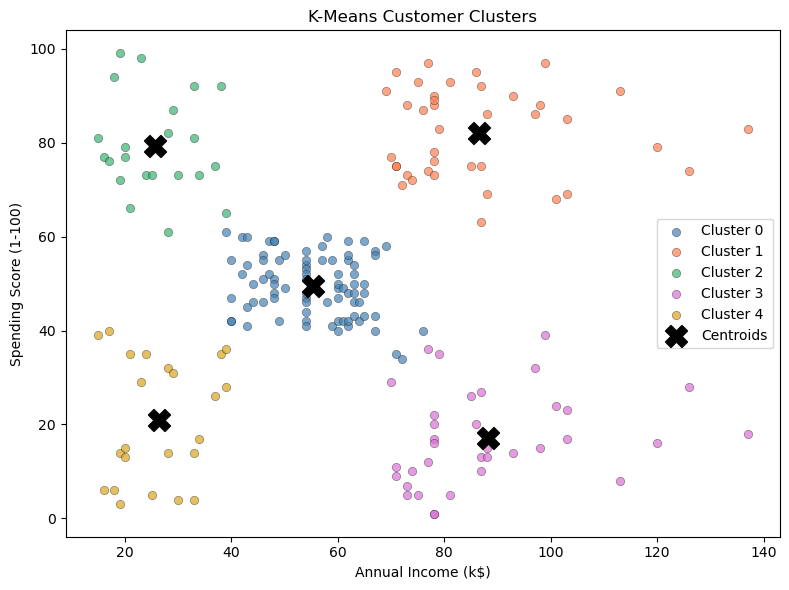

In [10]:
# Cluster scatter plot with centroids
colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid', 'goldenrod']
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
for c in range(k_optimal):
    mask = df['Cluster'] == c
    plt.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        color=colors[c], label=f'Cluster {c}', alpha=0.7, edgecolors='k', linewidths=0.3
    )

plt.scatter(
    centroids_orig[:, 0], centroids_orig[:, 1],
    s=250, c='black', marker='X', label='Centroids', zorder=5
)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('K-Means Customer Clusters')
plt.legend()
plt.tight_layout()
plt.show()

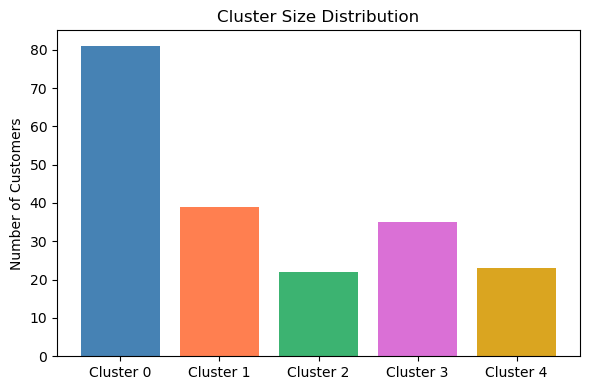

In [11]:
# Cluster size bar chart
cluster_sizes = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar([f'Cluster {c}' for c in cluster_sizes.index], cluster_sizes.values, color=colors)
plt.ylabel('Number of Customers')
plt.title('Cluster Size Distribution')
plt.tight_layout()
plt.show()